In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

First 5 Rows
   Survived  Pclass  Age   Fare     Sex
0         0       3   22   7.25    Male
1         1       1   38  71.28  Female
2         1       2   26   7.92  Female
3         0       3   35   8.05    Male
4         1       1   28  53.10  Female

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  10 non-null     int64  
 1   Pclass    10 non-null     int64  
 2   Age       10 non-null     int64  
 3   Fare      10 non-null     float64
 4   Sex       10 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 532.0+ bytes
None

Statistical Summary
        Survived     Pclass        Age      Fare
count  10.000000  10.000000  10.000000  10.00000
mean    0.600000   1.900000  30.800000  29.45500
std     0.516398   0.875595   8.416914  28.25523
min     0.000000   1.000000  19.000000   7.25000
25%     0.0000

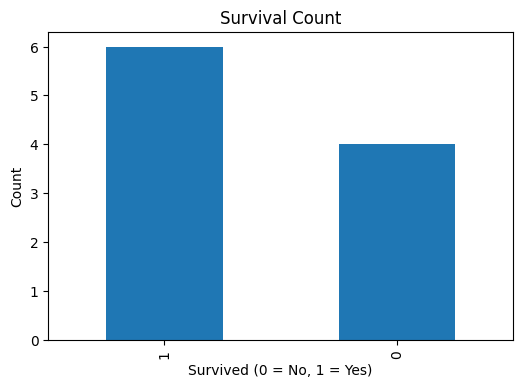

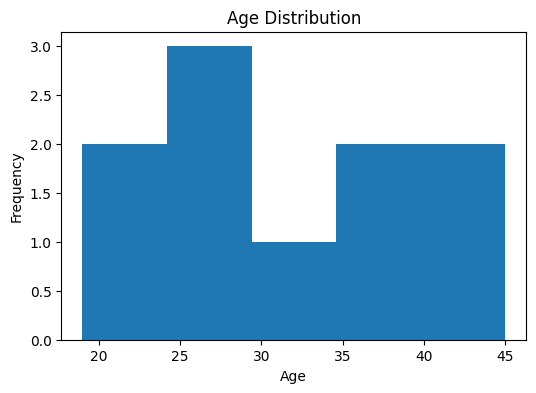


Correlation Matrix
          Survived    Pclass       Age      Fare
Survived  1.000000 -0.589768 -0.480594  0.563668
Pclass   -0.589768  1.000000  0.117597 -0.813680
Age      -0.480594  0.117597  1.000000 -0.088082
Fare      0.563668 -0.813680 -0.088082  1.000000


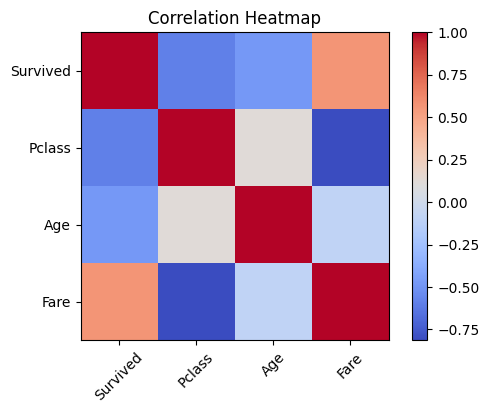


Key Insights
1. Female passengers had higher survival.
2. First-class passengers survived more.
3. Fare has a positive relationship with survival.
4. Age has a weak influence on survival.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create sample Titanic dataset
data = {
    "Survived": [0,1,1,0,1,0,1,1,0,1],
    "Pclass": [3,1,2,3,1,2,1,3,2,1],
    "Age": [22,38,26,35,28,40,19,30,45,25],
    "Fare": [7.25,71.28,7.92,8.05,53.10,13.00,30.00,8.45,15.50,80.00],
    "Sex": ["Male","Female","Female","Male","Female","Male","Female","Male","Male","Female"]
}

df = pd.DataFrame(data)

# Display dataset
print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# -------------------------
# Survival Count
# -------------------------
plt.figure(figsize=(6,4))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# -------------------------
# Age Distribution
# -------------------------
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=5)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# Correlation Matrix
# -------------------------
numeric_df = df[["Survived","Pclass","Age","Fare"]]

print("\nCorrelation Matrix")
print(numeric_df.corr())

plt.figure(figsize=(6,4))
plt.imshow(numeric_df.corr(), cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=45)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

plt.title("Correlation Heatmap")
plt.show()

print("\nKey Insights")
print("1. Female passengers had higher survival.")
print("2. First-class passengers survived more.")
print("3. Fare has a positive relationship with survival.")
print("4. Age has a weak influence on survival.")